#Line Chart

In [ ]:
# Install datasets Library (if not already installed)
# !pip install datasets

# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  # we will use this for plotting

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

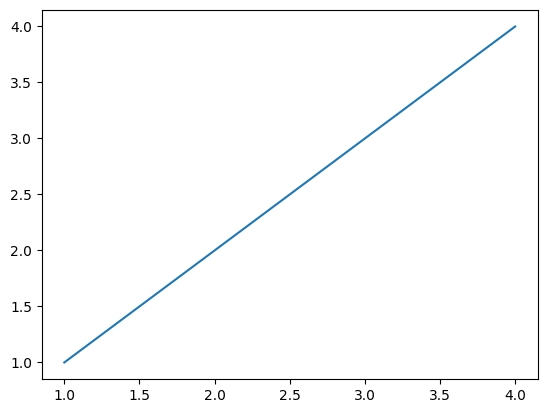

In [ ]:
x = [1,2,3,4]
y = [1,2,3,4]

plt.plot(x, y)
plt.show() #get rid of the ID numbers about the graph, and display all open figures

In [ ]:
df.job_posted_date.head()

,job_posted_date
0,2023-06-16 13:44:15
1,2023-01-14 13:18:07
2,2023-10-10 13:14:55
3,2023-07-04 13:01:41
4,2023-08-07 14:29:36


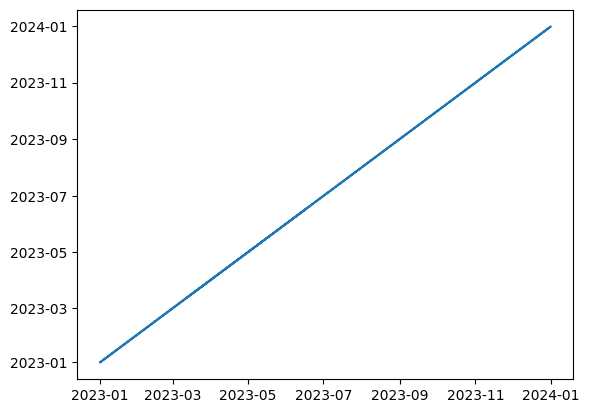

In [ ]:
plt.plot(df.job_posted_date, df.job_posted_date)

In [ ]:
date_counts = df.job_posted_date.value_counts()
date_counts = date_counts.sort_index()

In [ ]:
df['job_posted_month'] = df['job_posted_date'].dt.month

In [ ]:
monthly_counts = df.job_posted_month.value_counts()
monthly_counts = monthly_counts.sort_index()
monthly_counts
#this is a series

,count
job_posted_month,
1,91822
2,64578
3,64084
4,62919
5,52104
6,61572
7,63777
8,75162
9,62359


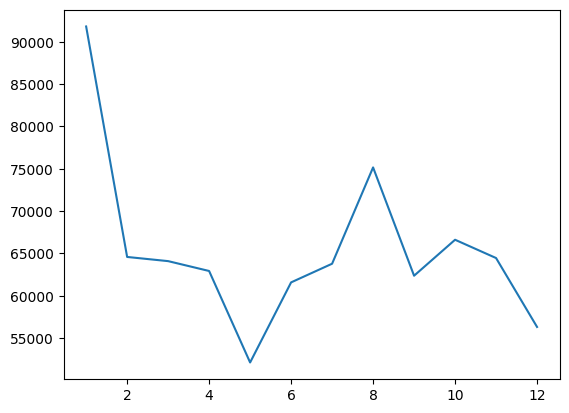

In [ ]:
plt.plot(monthly_counts.index, monthly_counts)
#plt.plot(monthly_counts.index, monthly_counts.values)
#does the same thing
#uses series

##Series vs DataFrame

In [ ]:
series = pd.Series([10,20,30,40,50], index=['a','b','c','d','e'])

In [ ]:
series.index

Index(['a', 'b', 'c', 'd', 'e'], dtype='object')

In [ ]:
series.values

array([10, 20, 30, 40, 50])

#Bar Chart

In [ ]:
job_counts = df.job_title_short.value_counts()

<BarContainer object of 10 artists>

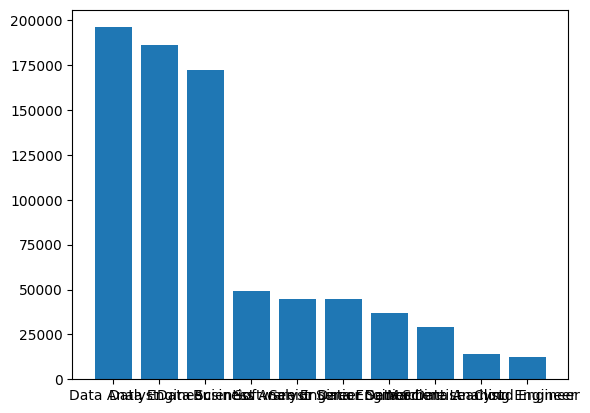

In [ ]:
plt.bar(job_counts.index, job_counts)

<BarContainer object of 10 artists>

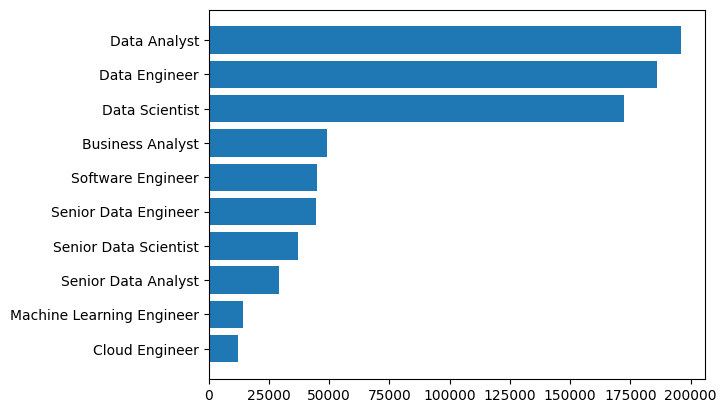

In [ ]:
job_counts = job_counts.sort_values(ascending=True)
plt.barh(job_counts.index, job_counts)
#horizontal bar chart

##Tidying up the graphs

In [ ]:
job_counts = df.job_title_short.value_counts()
job_counts

,count
job_title_short,
Data Analyst,196075
Data Engineer,186241
Data Scientist,172286
Business Analyst,49063
Software Engineer,44929
Senior Data Engineer,44563
Senior Data Scientist,36957
Senior Data Analyst,29216
Machine Learning Engineer,14080


<BarContainer object of 10 artists>

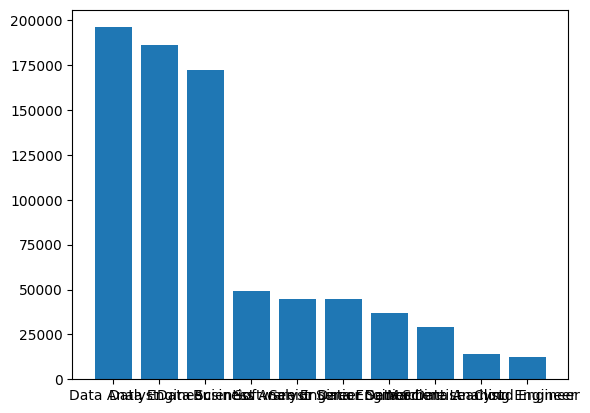

In [ ]:
plt.bar(job_counts.index, job_counts)

Title

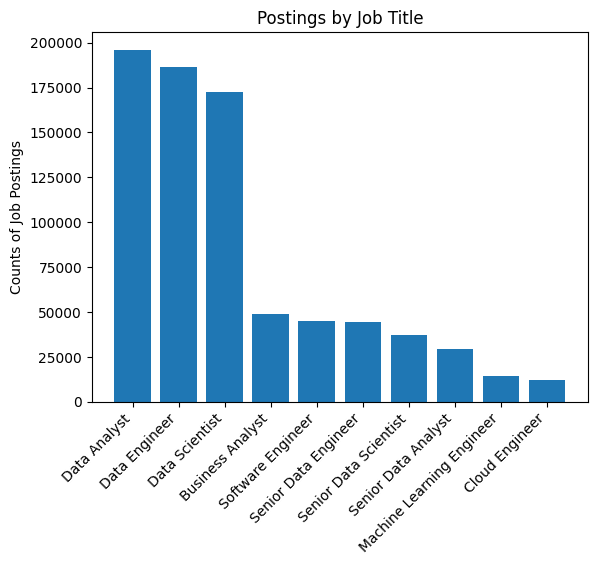

In [ ]:
plt.bar(job_counts.index, job_counts)
plt.title('Postings by Job Title')
plt.ylabel('Counts of Job Postings')
plt.xticks(rotation=45, ha='right')
plt.show()

Plotting with pandas

Plotting with series

In [ ]:
job_counts = df.job_title_short.value_counts()
job_counts

,count
job_title_short,
Data Analyst,196075
Data Engineer,186241
Data Scientist,172286
Business Analyst,49063
Software Engineer,44929
Senior Data Engineer,44563
Senior Data Scientist,36957
Senior Data Analyst,29216
Machine Learning Engineer,14080


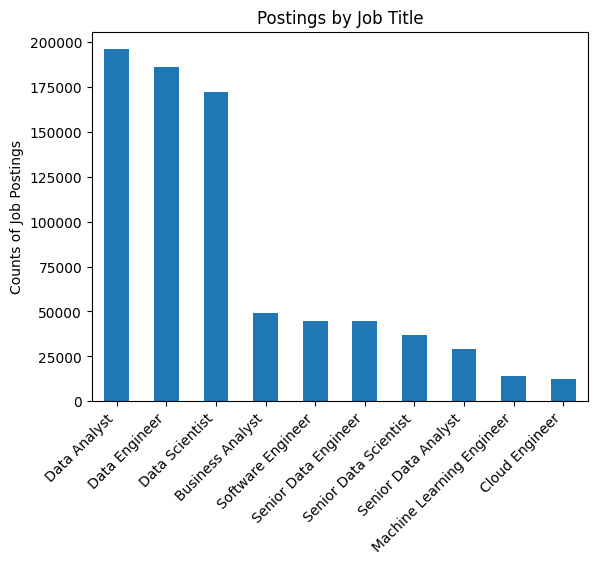

In [ ]:
job_counts.plot(kind='bar')
plt.title('Postings by Job Title')
plt.ylabel('Counts of Job Postings')
plt.xlabel(' ')
plt.xticks(rotation=45, ha='right')
plt.show()

Plotting with DataFrame

In [ ]:
df[['job_posted_date', 'salary_year_avg']].dropna(subset=['salary_year_avg'])


,job_posted_date,salary_year_avg
28,2023-08-01 13:37:57,109500.0
77,2023-06-26 14:22:54,140000.0
92,2023-02-21 13:29:59,120000.0
100,2023-07-31 13:01:18,228222.0
109,2023-10-12 13:02:19,89000.0
...,...,...
785624,2023-08-31 06:02:16,139216.0
785641,2023-01-04 16:36:07,150000.0
785648,2023-04-12 06:02:51,221875.0
785682,2023-03-04 06:16:08,157500.0


In [ ]:
monthly_salary = df.groupby('job_posted_month')['salary_year_avg'].mean()
monthly_salary
type(monthly_salary)

pandas.core.series.Series

(100000.0, 132110.4005551723)

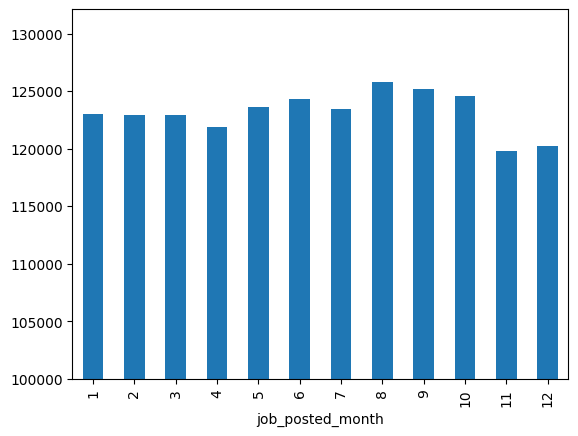

In [ ]:
 monthly_salary.plot(kind= 'bar')
 plt.ylim(100000)

Exercise

Text(0.5, 1.0, 'Median Salary by Job Title')

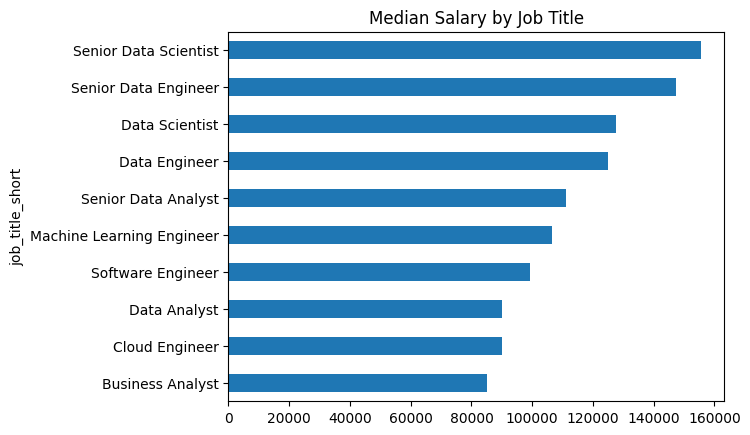

In [ ]:
salary_median = df.groupby('job_title_short')['salary_year_avg'].median().sort_values()
salary_median.plot(kind='barh')
plt.title('Median Salary by Job Title')

